In [1]:
# ══════════════════════════════════════════════════════
# PARAMÈTRES GLOBAUX — modifier ici uniquement
# ══════════════════════════════════════════════════════

TAILLE_CELLULE = 1.0    # taille des mailles en degrés (ex: 0.5, 1.0, 2.0)
ANNEE_DEBUT    = 1970   # début de la période
ANNEE_FIN      = 2021   # fin de la période
ANNEE_SPLIT    = 2015   # séparation train / test

FICHIERS_GTD = [
    "../data/globalterrorismdb_0522dist.xlsx",
    "../data/globalterrorismdb_2021Jan-June_1222dist.xlsx",
]

COLONNES_UTILES = [
    "eventid",
    "iyear", "imonth", "iday",
    "country_txt", "region_txt",
    "latitude", "longitude",
    "attacktype1_txt",
    "targtype1_txt",
    "gname",
    "weaptype1_txt",
    "nkill", "nwound",
    "success", "suicide"
]

print("Paramètres chargés !")
print(f"  Taille cellule : {TAILLE_CELLULE}°")
print(f"  Période        : {ANNEE_DEBUT}–{ANNEE_FIN}")
print(f"  Train/Test     : ≤{ANNEE_SPLIT} / >{ANNEE_SPLIT}")

Paramètres chargés !
  Taille cellule : 1.0°
  Période        : 1970–2021
  Train/Test     : ≤2015 / >2015


In [2]:
import pandas as pd
import numpy as np

# ── CHARGEMENT ET FUSION DES FICHIERS GTD ──
print("Chargement des données...")

dfs = []
for fichier in FICHIERS_GTD:
    df_temp = pd.read_excel(fichier, engine="openpyxl")
    cols = [c for c in COLONNES_UTILES if c in df_temp.columns]
    dfs.append(df_temp[cols])
    print(f"  {fichier.split('/')[-1]} — {len(df_temp):,} lignes")

df = pd.concat(dfs, ignore_index=True)

# ── NETTOYAGE ──
df = df[df["iyear"].between(ANNEE_DEBUT, ANNEE_FIN)]
df = df.dropna(subset=["latitude", "longitude"])
df["nkill"]  = df["nkill"].fillna(0).clip(lower=0)
df["nwound"] = df["nwound"].fillna(0).clip(lower=0)

print(f"\nDonnées chargées et nettoyées !")
print(f"  Lignes totales : {len(df):,}")
print(f"  Période        : {df['iyear'].min()}–{df['iyear'].max()}")

Chargement des données...
  globalterrorismdb_0522dist.xlsx — 209,706 lignes
  globalterrorismdb_2021Jan-June_1222dist.xlsx — 4,960 lignes

Données chargées et nettoyées !
  Lignes totales : 209,939
  Période        : 1970–2021


In [3]:
# ── DÉCOUPAGE EN CELLULES ──
df["cell_lat"] = (df["latitude"]  // TAILLE_CELLULE) * TAILLE_CELLULE
df["cell_lon"] = (df["longitude"] // TAILLE_CELLULE) * TAILLE_CELLULE
df["cell_id"]  = df["cell_lat"].astype(str) + "_" + df["cell_lon"].astype(str)

print(f"Cellules distinctes : {df['cell_id'].nunique():,}")

# ── AGRÉGATION PAR CELLULE ET ANNÉE ──
grid = df.groupby(["cell_id", "cell_lat", "cell_lon", "iyear"]).agg(
    nb_incidents = ("eventid", "count"),
    nb_morts     = ("nkill", "sum"),
    nb_blesses   = ("nwound", "sum"),
).reset_index()

# ── AJOUT DES ZÉROS (cellules sans attentat) ──
toutes_les_annees   = range(ANNEE_DEBUT, ANNEE_FIN + 1)
toutes_les_cellules = df[["cell_id", "cell_lat", "cell_lon"]].drop_duplicates()

index_complet = toutes_les_cellules.merge(
    pd.DataFrame({"iyear": toutes_les_annees}), how="cross"
)

grid = index_complet.merge(grid, on=["cell_id", "cell_lat", "cell_lon", "iyear"], how="left")
grid[["nb_incidents", "nb_morts", "nb_blesses"]] = grid[["nb_incidents", "nb_morts", "nb_blesses"]].fillna(0)

# ── VARIABLE CIBLE ──
# Classification : présence ou absence d'attentat
grid["target_clf"] = (grid["nb_incidents"] > 0).astype(int)
# Régression : nombre d'attentats
grid["target_reg"] = grid["nb_incidents"]

# ── FEATURE ENGINEERING ──
grid = grid.sort_values(["cell_id", "iyear"]).reset_index(drop=True).copy()

grid["incidents_annee_precedente"] = (
    grid.groupby("cell_id")["nb_incidents"].shift(1).fillna(0)
)
grid["moyenne_3ans"] = (
    grid.groupby("cell_id")["nb_incidents"]
    .shift(1)
    .groupby(grid["cell_id"])
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
    .fillna(0)
)
grid["moyenne_5ans"] = (
    grid.groupby("cell_id")["nb_incidents"]
    .shift(1)
    .groupby(grid["cell_id"])
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
    .fillna(0)
)
grid["nb_annees_actives"] = (
    grid.groupby("cell_id")["target_clf"]
    .shift(1)
    .fillna(0)
    .groupby(grid["cell_id"])
    .transform(lambda x: x.expanding().sum())
)

print(f"Grille complète : {len(grid):,} lignes")
print(f"Taux de cellules actives : {grid['target_clf'].mean()*100:.1f}%")

Cellules distinctes : 4,085
Grille complète : 212,420 lignes
Taux de cellules actives : 12.6%


In [4]:
# ── FEATURES ET SÉPARATION TRAIN/TEST ──

FEATURES = [
    "cell_lat",
    "cell_lon",
    "iyear",
    "incidents_annee_precedente",
    "moyenne_3ans",
    "moyenne_5ans",
    "nb_annees_actives",
]

train = grid[grid["iyear"] <= ANNEE_SPLIT]
test  = grid[grid["iyear"] >  ANNEE_SPLIT]

# Classification
X_train = train[FEATURES]
y_train_clf = train["target_clf"]
X_test  = test[FEATURES]
y_test_clf  = test["target_clf"]

# Régression
y_train_reg = train["target_reg"]
y_test_reg  = test["target_reg"]

print(f"Train : {len(X_train):,} lignes ({train['iyear'].min()}–{train['iyear'].max()})")
print(f"Test  : {len(X_test):,} lignes ({test['iyear'].min()}–{test['iyear'].max()})")
print(f"\nTaux positifs train : {y_train_clf.mean()*100:.1f}%")
print(f"Taux positifs test  : {y_test_clf.mean()*100:.1f}%")

Train : 187,910 lignes (1970–2015)
Test  : 24,510 lignes (2016–2021)

Taux positifs train : 11.0%
Taux positifs test  : 25.4%


In [5]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

# ── NORMALISATION ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

resultats = {}

# ── 1. RÉGRESSION LINÉAIRE ──
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train_reg)
y_pred_linreg = lr_reg.predict(X_test_scaled).clip(0)

resultats["Régression Linéaire"] = {
    "RMSE" : np.sqrt(mean_squared_error(y_test_reg, y_pred_linreg)),
    "MAE"  : mean_absolute_error(y_test_reg, y_pred_linreg),
    "R²"   : r2_score(y_test_reg, y_pred_linreg),
}
print("=== RÉGRESSION LINÉAIRE ===")
for k, v in resultats["Régression Linéaire"].items():
    print(f"  {k} : {v:.4f}")

# ── 2. RÉGRESSION LOGISTIQUE ──
lr_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_clf.fit(X_train_scaled, y_train_clf)
y_pred_lr  = lr_clf.predict(X_test_scaled)
y_proba_lr = lr_clf.predict_proba(X_test_scaled)[:, 1]

print("\n=== RÉGRESSION LOGISTIQUE ===")
print(classification_report(y_test_clf, y_pred_lr))
print(f"  AUC-ROC : {roc_auc_score(y_test_clf, y_proba_lr):.4f}")
resultats["Régression Logistique"] = {"AUC-ROC": roc_auc_score(y_test_clf, y_proba_lr)}

# ── 3. RANDOM FOREST ──
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_clf)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test_clf, y_pred_rf))
print(f"  AUC-ROC : {roc_auc_score(y_test_clf, y_proba_rf):.4f}")
resultats["Random Forest"] = {"AUC-ROC": roc_auc_score(y_test_clf, y_proba_rf)}

# ── 4. XGBOOST ──
xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=len(y_train_clf[y_train_clf==0]) / len(y_train_clf[y_train_clf==1]),
    random_state=42, n_jobs=-1, eval_metric="logloss", verbosity=0
)
xgb.fit(X_train, y_train_clf)
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST ===")
print(classification_report(y_test_clf, y_pred_xgb))
print(f"  AUC-ROC : {roc_auc_score(y_test_clf, y_proba_xgb):.4f}")
resultats["XGBoost"] = {"AUC-ROC": roc_auc_score(y_test_clf, y_proba_xgb)}

print("\n=== RÉCAPITULATIF AUC-ROC ===")
for modele, scores in resultats.items():
    if "AUC-ROC" in scores:
        print(f"  {modele:25s} : {scores['AUC-ROC']:.4f}")

=== RÉGRESSION LINÉAIRE ===
  RMSE : 11.5996
  MAE : 2.0011
  R² : 0.5457

=== RÉGRESSION LOGISTIQUE ===
              precision    recall  f1-score   support

           0       0.91      0.63      0.74     18293
           1       0.43      0.82      0.56      6217

    accuracy                           0.67     24510
   macro avg       0.67      0.72      0.65     24510
weighted avg       0.79      0.67      0.70     24510

  AUC-ROC : 0.8140

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.87      0.90      0.89     18293
           1       0.68      0.61      0.64      6217

    accuracy                           0.83     24510
   macro avg       0.78      0.76      0.77     24510
weighted avg       0.82      0.83      0.83     24510

  AUC-ROC : 0.8366

=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.93      0.57      0.71     18293
           1       0.41      0.87      0.56      6217


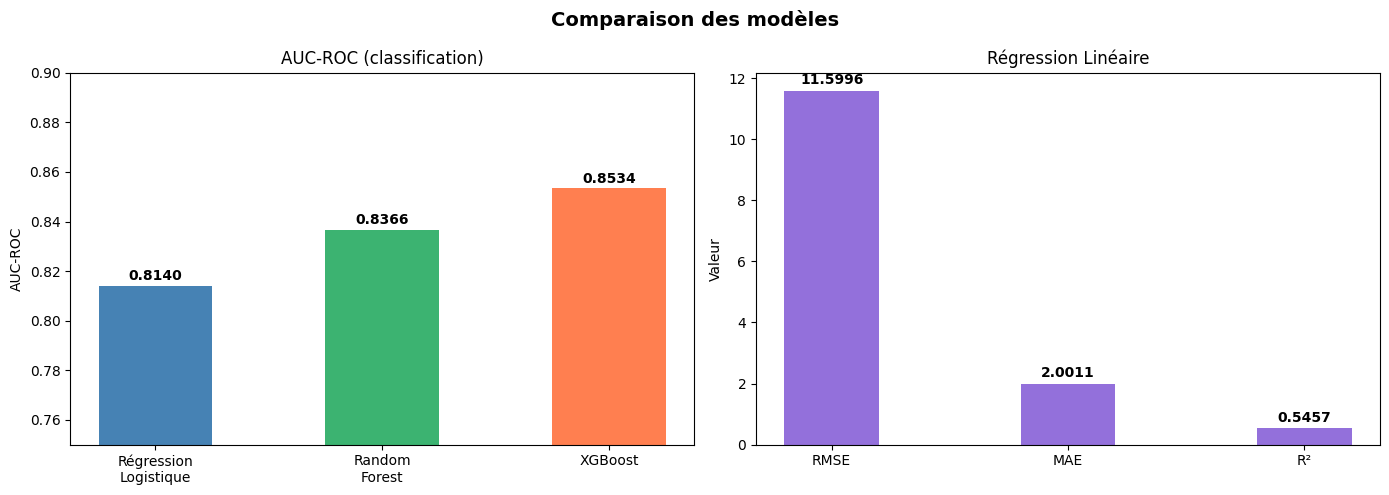

Graphique sauvegardé !


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison des modèles", fontsize=14, fontweight="bold")

# AUC-ROC
modeles = ["Régression\nLogistique", "Random\nForest", "XGBoost"]
aucs    = [0.8140, 0.8366, 0.8534]
colors  = ["steelblue", "mediumseagreen", "coral"]

bars = axes[0].bar(modeles, aucs, color=colors, width=0.5)
axes[0].set_ylim(0.75, 0.90)
axes[0].set_title("AUC-ROC (classification)")
axes[0].set_ylabel("AUC-ROC")
for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", va="bottom", fontweight="bold")

# Régression linéaire
metriques = ["RMSE", "MAE", "R²"]
valeurs   = [11.5996, 2.0011, 0.5457]
bars2 = axes[1].bar(metriques, valeurs, color="mediumpurple", width=0.4)
axes[1].set_title("Régression Linéaire")
axes[1].set_ylabel("Valeur")
for bar, val in zip(bars2, valeurs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val:.4f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/comparaison_modeles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé !")

In [7]:
# ══════════════════════════════════════════════════════
# PARAMÈTRES GLOBAUX — modifier ici uniquement
# ══════════════════════════════════════════════════════

TAILLE_CELLULE = 1.0      # taille des mailles en degrés (ex: 0.5, 1.0, 2.0, 5.0)
ANNEE_DEBUT    = 1970     # début de la période
ANNEE_FIN      = 2021     # fin de la période
ANNEE_SPLIT    = 2015     # séparation train / test

# Fréquence temporelle : "M" (mensuelle), "Q" (trimestrielle), "6M" (semestrielle), "Y" (annuelle)
PERIODE = "Q"

FICHIERS_GTD = [
    "../data/globalterrorismdb_0522dist.xlsx",
    "../data/globalterrorismdb_2021Jan-June_1222dist.xlsx",
]

COLONNES_UTILES = [
    "eventid",
    "iyear", "imonth", "iday",
    "country_txt", "region_txt",
    "latitude", "longitude",
    "attacktype1_txt", "targtype1_txt",
    "gname", "weaptype1_txt",
    "nkill", "nwound",
    "success", "suicide"
]

PERIODE_LABEL = {"M": "mensuelle", "Q": "trimestrielle", "6M": "semestrielle", "Y": "annuelle"}

print("Paramètres chargés !")
print(f"  Taille cellule : {TAILLE_CELLULE}°")
print(f"  Période        : {ANNEE_DEBUT}–{ANNEE_FIN}")
print(f"  Fréquence      : {PERIODE_LABEL[PERIODE]} ({PERIODE})")
print(f"  Train/Test     : ≤{ANNEE_SPLIT} / >{ANNEE_SPLIT}")

Paramètres chargés !
  Taille cellule : 1.0°
  Période        : 1970–2021
  Fréquence      : trimestrielle (Q)
  Train/Test     : ≤2015 / >2015


In [8]:
import pandas as pd
import numpy as np

print("Chargement des données...")

dfs = []
for fichier in FICHIERS_GTD:
    df_temp = pd.read_excel(fichier, engine="openpyxl")
    cols = [c for c in COLONNES_UTILES if c in df_temp.columns]
    dfs.append(df_temp[cols])
    print(f"  {fichier.split('/')[-1]} — {len(df_temp):,} lignes")

df = pd.concat(dfs, ignore_index=True)

# Nettoyage
df = df[df["iyear"].between(ANNEE_DEBUT, ANNEE_FIN)]
df = df.dropna(subset=["latitude", "longitude"])
df["imonth"] = df["imonth"].replace(0, 1)   # mois=0 → janvier par défaut
df["iday"]   = df["iday"].replace(0, 1)     # jour=0 → 1er par défaut
df["nkill"]  = df["nkill"].fillna(0).clip(lower=0)
df["nwound"] = df["nwound"].fillna(0).clip(lower=0)

# Colonne date unifiée
df["date"] = pd.to_datetime(
    df[["iyear", "imonth", "iday"]].rename(columns={"iyear": "year", "imonth": "month", "iday": "day"}),
    errors="coerce"
)
df = df.dropna(subset=["date"])

print(f"\nDonnées prêtes : {len(df):,} lignes | {df['iyear'].min()}–{df['iyear'].max()}")

Chargement des données...
  globalterrorismdb_0522dist.xlsx — 209,706 lignes
  globalterrorismdb_2021Jan-June_1222dist.xlsx — 4,960 lignes

Données prêtes : 209,939 lignes | 1970–2021


In [9]:
def construire_grille(df, taille_cellule, periode, annee_debut, annee_fin):
    """
    Construit une grille spatio-temporelle à partir du DataFrame GTD.

    Paramètres
    ----------
    df             : DataFrame nettoyé avec colonnes date, latitude, longitude
    taille_cellule : taille des mailles en degrés (ex: 0.5, 1.0, 2.0)
    periode        : fréquence pandas (ex: "M", "Q", "6M", "Y")
    annee_debut    : première année à inclure
    annee_fin      : dernière année à inclure

    Retourne
    --------
    DataFrame avec une ligne par (cell_id, periode_id) et les agrégats
    nb_incidents, nb_morts, nb_blesses — zéros inclus pour les périodes sans attaque.
    """

    df = df.copy()

    # 1. Assignation des cellules géographiques
    df["cell_lat"] = (df["latitude"]  // taille_cellule) * taille_cellule
    df["cell_lon"] = (df["longitude"] // taille_cellule) * taille_cellule
    df["cell_id"]  = df["cell_lat"].astype(str) + "_" + df["cell_lon"].astype(str)

    # 2. Assignation de la période temporelle
    df["periode_id"] = df["date"].dt.to_period(periode)

    # 3. Agrégation
    agg = df.groupby(["cell_id", "cell_lat", "cell_lon", "periode_id"]).agg(
        nb_incidents = ("eventid", "count"),
        nb_morts     = ("nkill",   "sum"),
        nb_blesses   = ("nwound",  "sum"),
    ).reset_index()

    # 4. Index complet : toutes les cellules × toutes les périodes (pour inclure les zéros)
    date_debut  = pd.Timestamp(f"{annee_debut}-01-01")
    date_fin    = pd.Timestamp(f"{annee_fin}-12-31")
    toutes_periodes = pd.period_range(start=date_debut, end=date_fin, freq=periode)

    cellules = df[["cell_id", "cell_lat", "cell_lon"]].drop_duplicates()
    index_complet = cellules.merge(
        pd.DataFrame({"periode_id": toutes_periodes}), how="cross"
    )

    # 5. Jointure et remplissage des zéros
    grille = index_complet.merge(agg, on=["cell_id", "cell_lat", "cell_lon", "periode_id"], how="left")
    grille[["nb_incidents", "nb_morts", "nb_blesses"]] = (
        grille[["nb_incidents", "nb_morts", "nb_blesses"]].fillna(0).astype(int)
    )

    # 6. Colonnes utiles pour le feature engineering
    grille["periode_str"] = grille["periode_id"].astype(str)
    grille["annee"]       = grille["periode_id"].apply(lambda p: p.start_time.year)

    grille = grille.sort_values(["cell_id", "periode_id"]).reset_index(drop=True)

    return grille


# ── APPEL ──
grille = construire_grille(df, TAILLE_CELLULE, PERIODE, ANNEE_DEBUT, ANNEE_FIN)

print(f"Grille construite !")
print(f"  Cellules distinctes : {grille['cell_id'].nunique():,}")
print(f"  Périodes distinctes : {grille['periode_id'].nunique():,}")
print(f"  Lignes totales      : {len(grille):,}")
print(f"  Taux actif          : {(grille['nb_incidents'] > 0).mean()*100:.1f}%")
grille.head(10)

Grille construite !
  Cellules distinctes : 4,085
  Périodes distinctes : 208
  Lignes totales      : 849,680
  Taux actif          : 5.9%


,cell_id,cell_lat,cell_lon,periode_id,nb_incidents,nb_morts,nb_blesses,periode_str,annee
0,-1.0_-71.0,-1.0,-71.0,1970Q1,0,0,0,1970Q1,1970
1,-1.0_-71.0,-1.0,-71.0,1970Q2,0,0,0,1970Q2,1970
2,-1.0_-71.0,-1.0,-71.0,1970Q3,0,0,0,1970Q3,1970
3,-1.0_-71.0,-1.0,-71.0,1970Q4,0,0,0,1970Q4,1970
4,-1.0_-71.0,-1.0,-71.0,1971Q1,0,0,0,1971Q1,1971
5,-1.0_-71.0,-1.0,-71.0,1971Q2,0,0,0,1971Q2,1971
6,-1.0_-71.0,-1.0,-71.0,1971Q3,0,0,0,1971Q3,1971
7,-1.0_-71.0,-1.0,-71.0,1971Q4,0,0,0,1971Q4,1971
8,-1.0_-71.0,-1.0,-71.0,1972Q1,0,0,0,1972Q1,1972
9,-1.0_-71.0,-1.0,-71.0,1972Q2,0,0,0,1972Q2,1972


In [10]:
# ── TEST DE MODULARITÉ — comparer les fréquences ──
for freq in ["M", "Q", "6M", "Y"]:
    g = construire_grille(df, TAILLE_CELLULE, freq, ANNEE_DEBUT, ANNEE_FIN)
    print(f"  {PERIODE_LABEL[freq]:15s} ({freq}) → {g['periode_id'].nunique():4d} périodes "
          f"| {len(g):,} lignes | taux actif {(g['nb_incidents']>0).mean()*100:.1f}%")

  mensuelle       (M) →  624 périodes | 2,549,040 lignes | taux actif 3.0%
  trimestrielle   (Q) →  208 périodes | 849,680 lignes | taux actif 5.9%
  semestrielle    (6M) →  104 périodes | 424,840 lignes | taux actif 3.0%
  annuelle        (Y) →   52 périodes | 212,420 lignes | taux actif 12.6%


In [11]:
# ══════════════════════════════════════════════════════
# PARAMÈTRES DE CLASSIFICATION DES TRANSITIONS
# Basés sur le Tableau 3 de l'article (Salmon & Merino Laso)
# ══════════════════════════════════════════════════════

# Trois configurations disponibles (Section 3.3.1 de l'article) :
# "very_sensitive" : Ss=5,  Sc=15, Se=1
# "moderate"       : Ss=20, Sc=35, Se=2  ← recommandée
# "aggressive"     : Ss=25, Sc=50, Se=3

CONFIG_SEUILS = "moderate"

SEUILS = {
    "very_sensitive": {"Ss": 5,  "Sc": 15, "Se": 1},
    "moderate":       {"Ss": 20, "Sc": 35, "Se": 2},
    "aggressive":     {"Ss": 25, "Sc": 50, "Se": 3},
}

Ss = SEUILS[CONFIG_SEUILS]["Ss"]   # seuil Stable (±%)
Sc = SEUILS[CONFIG_SEUILS]["Sc"]   # seuil Changement (±%)
Se = SEUILS[CONFIG_SEUILS]["Se"]   # seuil Émergence (nb incidents min)

print(f"Configuration : {CONFIG_SEUILS}")
print(f"  Stable        : variation entre ±{Ss}%")
print(f"  Intensification : variation ≥ +{Sc}%")
print(f"  Déclin          : variation ≤ -{Sc}%")
print(f"  Émergence       : 0 → ≥{Se} incident(s)")
print(f"  Extinction      : ≥1 → 0 incident(s)")

Configuration : moderate
  Stable        : variation entre ±20%
  Intensification : variation ≥ +35%
  Déclin          : variation ≤ -35%
  Émergence       : 0 → ≥2 incident(s)
  Extinction      : ≥1 → 0 incident(s)


In [12]:
def classifier_transition(xt, xt1, Ss, Sc, Se):
    """
    Classifie la transition entre deux périodes consécutives pour une cellule.
    
    Implémente le Tableau 3 de Salmon & Merino Laso (2025) :
    
    - Émergence     : xt <= 0  et  xt+1 >= Se
    - Extinction    : xt >= 1  et  xt+1 == 0
    - Intensification : delta >= +Sc%
    - Déclin        : delta <= -Sc%
    - Stable        : -Ss% <= delta <= +Ss%
    - Intermédiaire : entre Ss et Sc (zone grise)
    
    Paramètres
    ----------
    xt   : nb incidents à la période t
    xt1  : nb incidents à la période t+1
    Ss   : seuil stable en %
    Sc   : seuil changement en %
    Se   : seuil émergence (nb incidents min)
    """
    # Émergence : zone inactive qui s'active
    if xt == 0 and xt1 >= Se:
        return "Émergence"
    
    # Xt=0 et xt1 < Se : trop peu d'incidents pour considérer une émergence
    if xt == 0:
        return "Stable"
    
    # Extinction : zone active qui disparaît
    if xt >= 1 and xt1 == 0:
        return "Extinction"
    
    # Calcul de la variation en %
    delta_pct = ((xt1 - xt) / xt) * 100
    
    # Intensification
    if delta_pct >= Sc:
        return "Intensification"
    
    # Déclin
    if delta_pct <= -Sc:
        return "Déclin"
    
    # Stable
    if -Ss <= delta_pct <= Ss:
        return "Stable"
    
    # Zone intermédiaire (entre Ss et Sc)
    return "Intermédiaire"


def construire_transitions(grille, Ss, Sc, Se):
    """
    Applique la classification des transitions à toute la grille.
    Pour chaque cellule, calcule la transition entre t et t+1.
    
    Retourne un DataFrame avec une colonne 'transition' par ligne.
    """
    g = grille.copy().sort_values(["cell_id", "periode_id"]).reset_index(drop=True)
    
    # Valeur de la période précédente (shift par cellule)
    g["nb_incidents_prev"] = g.groupby("cell_id")["nb_incidents"].shift(1)
    
    # Supprimer la première période de chaque cellule (pas de t-1)
    g = g.dropna(subset=["nb_incidents_prev"]).copy()
    g["nb_incidents_prev"] = g["nb_incidents_prev"].astype(int)
    
    # Appliquer la classification
    g["transition"] = g.apply(
        lambda row: classifier_transition(
            row["nb_incidents_prev"],
            row["nb_incidents"],
            Ss, Sc, Se
        ),
        axis=1
    )
    
    return g


# ── APPEL ──
# Utilise la grille construite précédemment avec construire_grille()
grille_transitions = construire_transitions(grille, Ss, Sc, Se)

print(f"Transitions calculées : {len(grille_transitions):,} lignes")
print(f"\nDistribution des transitions :")
dist = grille_transitions["transition"].value_counts()
for label, count in dist.items():
    pct = count / len(grille_transitions) * 100
    print(f"  {label:15s} : {count:6,}  ({pct:.1f}%)")

Transitions calculées : 845,595 lignes

Distribution des transitions :
  Stable          : 796,617  (94.2%)
  Extinction      : 24,332  (2.9%)
  Intensification :  8,263  (1.0%)
  Déclin          :  7,110  (0.8%)
  Émergence       :  6,924  (0.8%)
  Intermédiaire   :  2,349  (0.3%)


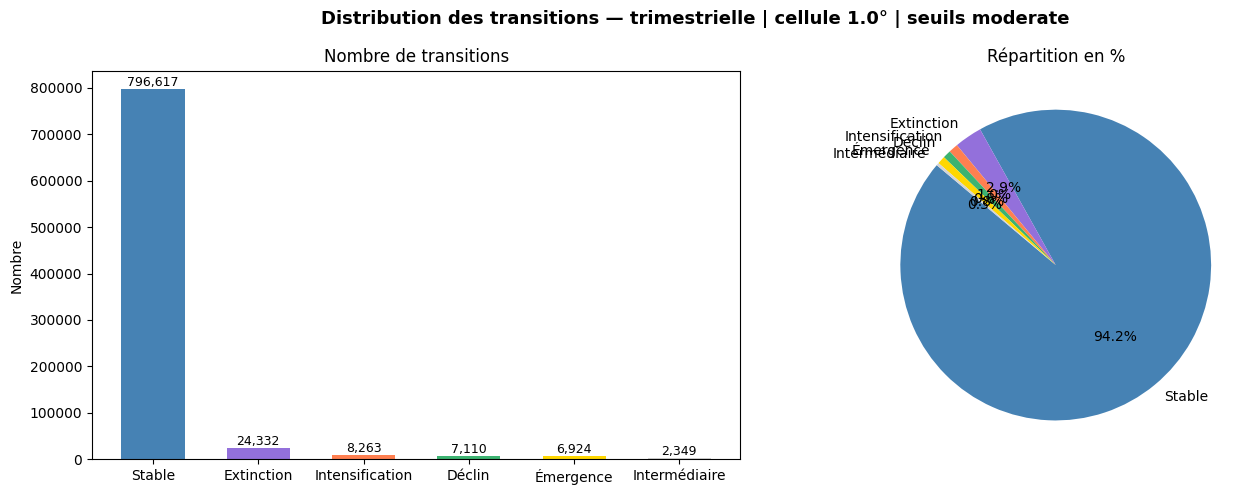

Graphique sauvegardé !


In [13]:
import matplotlib.pyplot as plt

COULEURS = {
    "Stable":           "steelblue",
    "Intensification":  "coral",
    "Déclin":           "mediumseagreen",
    "Émergence":        "gold",
    "Extinction":       "mediumpurple",
    "Intermédiaire":    "lightgray",
}

dist = grille_transitions["transition"].value_counts()
labels = dist.index.tolist()
values = dist.values.tolist()
colors = [COULEURS.get(l, "lightgray") for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Distribution des transitions — {PERIODE_LABEL[PERIODE]} | "
    f"cellule {TAILLE_CELLULE}° | seuils {CONFIG_SEUILS}",
    fontsize=13, fontweight="bold"
)

# Barres
bars = axes[0].bar(labels, values, color=colors, width=0.6)
axes[0].set_title("Nombre de transitions")
axes[0].set_ylabel("Nombre")
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{val:,}", ha="center", va="bottom", fontsize=9
    )

# Camembert
axes[1].pie(
    values, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=140,
    textprops={"fontsize": 10}
)
axes[1].set_title("Répartition en %")

plt.tight_layout()
plt.savefig("transitions_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé !")

In [14]:
# Comparer les distributions selon les 3 configurations de l'article
print(f"{'Transition':15s} | {'very_sensitive':>15s} | {'moderate':>10s} | {'aggressive':>12s}")
print("-" * 60)

resultats_configs = {}
for config, s in SEUILS.items():
    g = construire_transitions(grille, s["Ss"], s["Sc"], s["Se"])
    resultats_configs[config] = g["transition"].value_counts(normalize=True) * 100

toutes_classes = ["Stable", "Émergence", "Intensification", "Déclin", "Extinction", "Intermédiaire"]
for classe in toutes_classes:
    vs  = resultats_configs["very_sensitive"].get(classe, 0)
    mod = resultats_configs["moderate"].get(classe, 0)
    agg = resultats_configs["aggressive"].get(classe, 0)
    print(f"{classe:15s} | {vs:13.1f}%  | {mod:8.1f}%  | {agg:10.1f}%")

Transition      |  very_sensitive |   moderate |   aggressive
------------------------------------------------------------
Stable          |          92.0%  |     94.2%  |       94.8%
Émergence       |           2.9%  |      0.8%  |        0.4%
Intensification |           1.1%  |      1.0%  |        0.9%
Déclin          |           1.1%  |      0.8%  |        0.7%
Extinction      |           2.9%  |      2.9%  |        2.9%
Intermédiaire   |           0.1%  |      0.3%  |        0.3%


In [15]:
# ══════════════════════════════════════════════════════
# Cellule — Filtre des cellules inactives
# PARAMÈTRES DU FILTRE — modifier ici uniquement
# ══════════════════════════════════════════════════════

# Nombre minimum d'incidents total sur toute la période pour garder une cellule
SEUIL_INCIDENTS_MIN = 5

# Nombre minimum de périodes actives (nb_incidents > 0) pour garder une cellule
SEUIL_PERIODES_ACTIVES_MIN = 2

# ══════════════════════════════════════════════════════

def filtrer_cellules_actives(grille, seuil_incidents, seuil_periodes):
    """
    Filtre les cellules trop inactives sur toute la période.
    
    Paramètres
    ----------
    grille            : DataFrame retourné par construire_grille()
    seuil_incidents   : nb total d'incidents minimum sur toute la période
    seuil_periodes    : nb minimum de périodes avec au moins 1 incident
    
    Retourne
    --------
    grille filtrée + résumé des cellules conservées
    """
    # Calcul des stats par cellule sur toute la période
    stats = grille.groupby("cell_id").agg(
        total_incidents  = ("nb_incidents", "sum"),
        periodes_actives = ("nb_incidents", lambda x: (x > 0).sum()),
    ).reset_index()

    # Cellules qui passent les deux critères
    cellules_actives = stats[
        (stats["total_incidents"]  >= seuil_incidents) &
        (stats["periodes_actives"] >= seuil_periodes)
    ]["cell_id"]

    grille_filtree = grille[grille["cell_id"].isin(cellules_actives)].copy()

    # Résumé
    n_avant  = grille["cell_id"].nunique()
    n_apres  = grille_filtree["cell_id"].nunique()
    n_lignes_avant = len(grille)
    n_lignes_apres = len(grille_filtree)

    print(f"Filtre appliqué :")
    print(f"  Seuil incidents totaux   : ≥ {seuil_incidents}")
    print(f"  Seuil périodes actives   : ≥ {seuil_periodes}")
    print(f"\nCellules : {n_avant:,} → {n_apres:,} ({n_apres/n_avant*100:.1f}% conservées)")
    print(f"Lignes   : {n_lignes_avant:,} → {n_lignes_apres:,} ({n_lignes_apres/n_lignes_avant*100:.1f}% conservées)")

    return grille_filtree, stats


# ── APPEL ──
grille_filtree, stats_cellules = filtrer_cellules_actives(
    grille, SEUIL_INCIDENTS_MIN, SEUIL_PERIODES_ACTIVES_MIN
)

# Recalcul des transitions sur la grille filtrée
grille_transitions_filtree = construire_transitions(grille_filtree, Ss, Sc, Se)

print(f"\nDistribution des transitions APRÈS filtre :")
dist_filtree = grille_transitions_filtree["transition"].value_counts()
dist_avant   = grille_transitions["transition"].value_counts()

print(f"\n{'Transition':15s} | {'Avant':>10s} | {'Après':>10s} | {'Variation':>10s}")
print("-" * 55)
for label in ["Stable", "Émergence", "Intensification", "Déclin", "Extinction", "Intermédiaire"]:
    avant = dist_avant.get(label, 0)
    apres = dist_filtree.get(label, 0)
    pct_avant = avant / len(grille_transitions) * 100
    pct_apres = apres / len(grille_transitions_filtree) * 100
    print(f"{label:15s} | {pct_avant:8.1f}%  | {pct_apres:8.1f}%  | {pct_apres - pct_avant:+.1f}pp")

Filtre appliqué :
  Seuil incidents totaux   : ≥ 5
  Seuil périodes actives   : ≥ 2

Cellules : 4,085 → 2,022 (49.5% conservées)
Lignes   : 849,680 → 420,576 (49.5% conservées)

Distribution des transitions APRÈS filtre :

Transition      |      Avant |      Après |  Variation
-------------------------------------------------------
Stable          |     94.2%  |     89.2%  | -5.0pp
Émergence       |      0.8%  |      1.6%  | +0.8pp
Intensification |      1.0%  |      2.0%  | +1.0pp
Déclin          |      0.8%  |      1.7%  | +0.9pp
Extinction      |      2.9%  |      5.0%  | +2.1pp
Intermédiaire   |      0.3%  |      0.6%  | +0.3pp


In [16]:
# ══════════════════════════════════════════════════════
# PARAMÈTRES DU SOUS-ÉCHANTILLONNAGE — modifier ici
# ══════════════════════════════════════════════════════

# Stratégies disponibles (Tableau 4 de l'article) :
# "no_undersampling" : 100% — aucun sous-échantillonnage (baseline)
# "balanced_50"      : 50%  — classe stable réduite à 50%
# "balanced_25"      : 25%  — classe stable réduite à 25%
# "balanced_10"      : 10%  — classe stable réduite à 10%
# "balanced_5"       : 5%   — classe stable réduite à 5%
# "equal_classes"    : auto — toutes les classes égales à la plus petite

STRATEGIE = "balanced_25"

# ══════════════════════════════════════════════════════

def sous_echantillonner(grille_transitions, strategie, random_state=42):
    """
    Sous-échantillonne la classe Stable selon la stratégie choisie.
    Les classes minoritaires (Émergence, Intensification, Déclin, Extinction)
    sont toujours conservées intégralement.

    Paramètres
    ----------
    grille_transitions : DataFrame retourné par construire_transitions()
    strategie          : une des 6 stratégies du Tableau 4 de l'article
    random_state       : graine aléatoire pour reproductibilité

    Retourne
    --------
    DataFrame sous-échantillonné
    """
    RATIOS = {
        "no_undersampling": 1.00,
        "balanced_50":      0.50,
        "balanced_25":      0.25,
        "balanced_10":      0.10,
        "balanced_5":       0.05,
        "equal_classes":    None,   # calculé dynamiquement
    }

    if strategie not in RATIOS:
        raise ValueError(f"Stratégie inconnue : {strategie}. Choisir parmi {list(RATIOS.keys())}")

    # Séparer Stable et le reste
    df_stable     = grille_transitions[grille_transitions["transition"] == "Stable"]
    df_minorites  = grille_transitions[grille_transitions["transition"] != "Stable"]

    n_stable_initial = len(df_stable)

    if strategie == "equal_classes":
        # Taille cible = taille de la plus petite classe minoritaire
        n_cible = df_minorites["transition"].value_counts().min()
    elif strategie == "no_undersampling":
        n_cible = n_stable_initial
    else:
        n_cible = max(1, int(n_stable_initial * RATIOS[strategie]))

    # Sous-échantillonnage aléatoire du Stable
    df_stable_reduit = df_stable.sample(n=min(n_cible, n_stable_initial), random_state=random_state)

    # Recombinaison et mélange
    df_final = pd.concat([df_stable_reduit, df_minorites], ignore_index=True)
    df_final = df_final.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return df_final


# ── APPEL ──
grille_reequilibree = sous_echantillonner(grille_transitions_filtree, STRATEGIE)

# ── COMPARAISON AVANT / APRÈS ──
print(f"Stratégie : {STRATEGIE}")
print(f"\n{'Transition':15s} | {'Avant filtre':>12s} | {'Après filtre':>12s} | {'Rééquilibré':>12s}")
print("-" * 60)

dist_avant    = grille_transitions["transition"].value_counts()
dist_filtree  = grille_transitions_filtree["transition"].value_counts()
dist_reequil  = grille_reequilibree["transition"].value_counts()

for label in ["Stable", "Émergence", "Intensification", "Déclin", "Extinction", "Intermédiaire"]:
    a  = dist_avant.get(label, 0) / len(grille_transitions) * 100
    f  = dist_filtree.get(label, 0) / len(grille_transitions_filtree) * 100
    r  = dist_reequil.get(label, 0) / len(grille_reequilibree) * 100
    print(f"{label:15s} | {a:10.1f}%  | {f:10.1f}%  | {r:10.1f}%")

print(f"\nLignes totales : {len(grille_transitions):,} → {len(grille_transitions_filtree):,} → {len(grille_reequilibree):,}")

Stratégie : balanced_25

Transition      | Avant filtre | Après filtre |  Rééquilibré
------------------------------------------------------------
Stable          |       94.2%  |       89.2%  |       67.3%
Émergence       |        0.8%  |        1.6%  |        4.8%
Intensification |        1.0%  |        2.0%  |        5.9%
Déclin          |        0.8%  |        1.7%  |        5.1%
Extinction      |        2.9%  |        5.0%  |       15.2%
Intermédiaire   |        0.3%  |        0.6%  |        1.7%

Lignes totales : 845,595 → 418,554 → 138,663


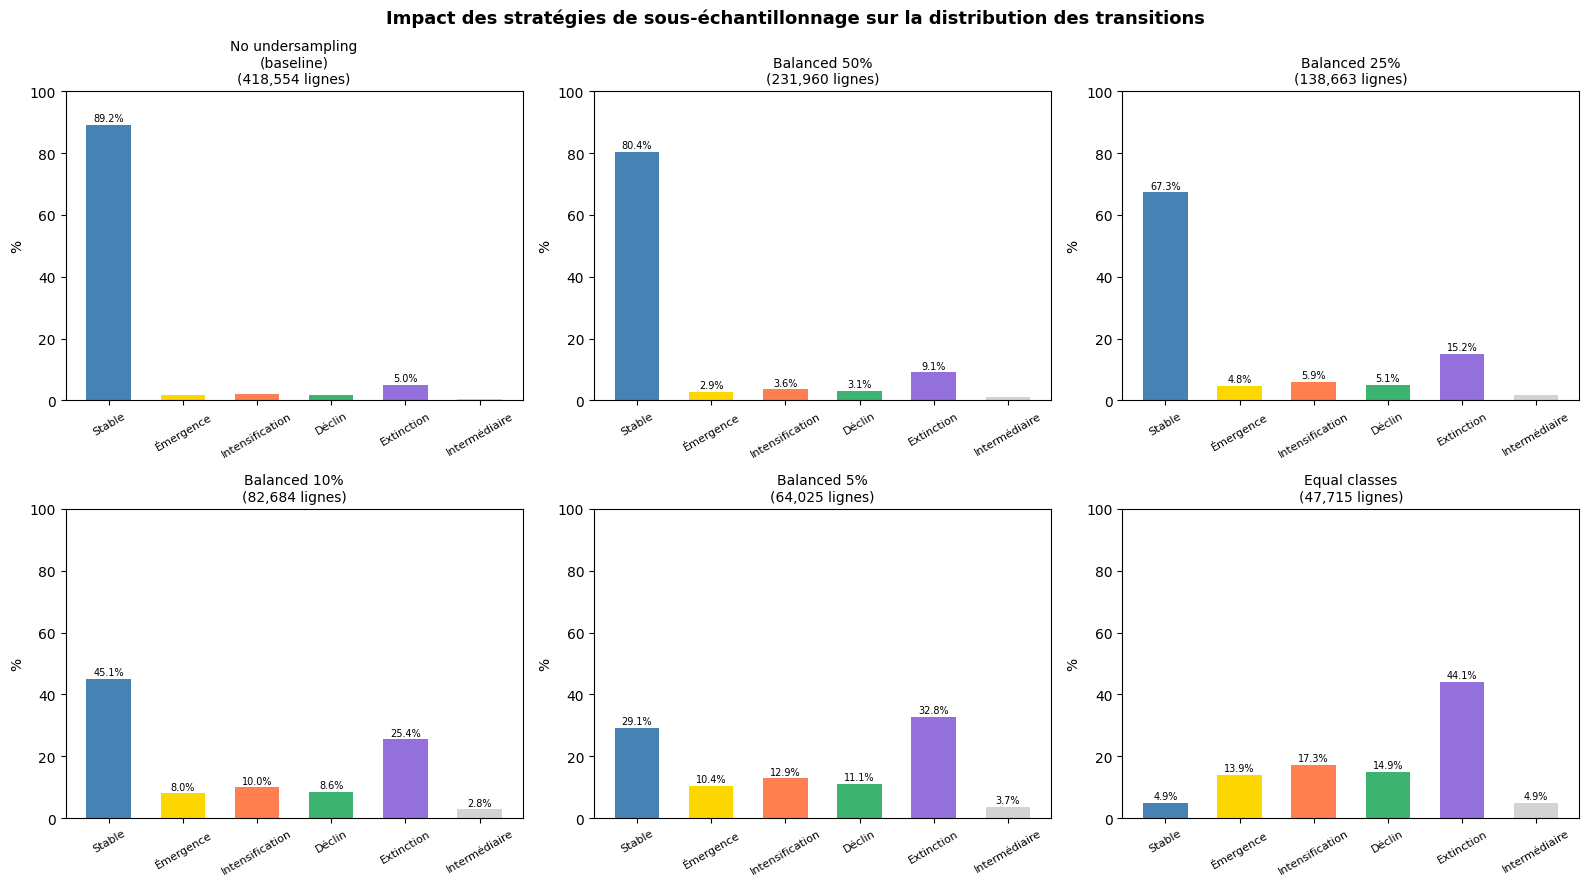

Graphique sauvegardé !


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Impact des stratégies de sous-échantillonnage sur la distribution des transitions",
             fontsize=13, fontweight="bold")

COULEURS = {
    "Stable":           "steelblue",
    "Intensification":  "coral",
    "Déclin":           "mediumseagreen",
    "Émergence":        "gold",
    "Extinction":       "mediumpurple",
    "Intermédiaire":    "lightgray",
}

STRATEGIES = ["no_undersampling", "balanced_50", "balanced_25",
              "balanced_10", "balanced_5", "equal_classes"]
LABELS_AFFICHAGE = ["No undersampling\n(baseline)", "Balanced 50%",
                    "Balanced 25%", "Balanced 10%", "Balanced 5%", "Equal classes"]

for ax, strat, titre in zip(axes.flatten(), STRATEGIES, LABELS_AFFICHAGE):
    g = sous_echantillonner(grille_transitions_filtree, strat)
    dist = g["transition"].value_counts(normalize=True) * 100

    classes = ["Stable", "Émergence", "Intensification", "Déclin", "Extinction", "Intermédiaire"]
    valeurs = [dist.get(c, 0) for c in classes]
    couleurs = [COULEURS[c] for c in classes]

    bars = ax.bar(classes, valeurs, color=couleurs, width=0.6)
    ax.set_title(f"{titre}\n({len(g):,} lignes)", fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_ylabel("%")
    ax.tick_params(axis='x', rotation=30, labelsize=8)

    for bar, val in zip(bars, valeurs):
        if val > 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("undersampling_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé !")